In [26]:
import numpy as np
import torch as th
import pandas as pd

In [27]:
class KNN:

    def __init__(self, nb_features, nb_classes, data, k, weighted = False):
        self.nb_features = nb_features
        self.nb_classes = nb_classes
        self.k = k
        self.weighted = weighted
        self.X = th.tensor(data['x'], dtype=th.float32)
        self.Y = th.tensor(data['y'], dtype=th.int64)


    # Ako imamo odgovore za upit racunamo i accuracy.
    def predict(self, query_data, verbose=True):

        nb_queries = len(query_data['x'])

        matches = 0
        predictions = []
        # konverzija query podataka u tensor
        Xq = th.tensor(query_data['x'], dtype=th.float32)


        for i in range(nb_queries):

            # Racunamo kvadriranu euklidsku udaljenost i uzimamo minimalnih k.

           #dists = th.sqrt(th.sum((self.X - Xq[i])**2, dim=1)) # Možemo ovako da počnemo,
           # ali ćemo računati kvadriranu euklidsku udaljenost koristeci cdist:
            dists = th.cdist(Xq[i].unsqueeze(0), self.X)  # shape [1, nb_train]
            dists = dists[0]  # shape [nb_train], da dobijemo 1D tensor

            dists_k, idxs = th.topk(dists, self.k, largest=False)

            classes = self.Y[idxs]
            #classes = th.gather(self.Y, 0, idxs)

            if self.weighted:
                w = 1 / (dists_k + 1e-8)  # zaštita od deljenja nulom
            else:
                w = th.ones(self.k) / self.k

            # Svaki red mnozimo svojim glasom i sabiramo glasove po kolonama.
            w_col = w.reshape(self.k, 1)
            classes_one_hot = th.nn.functional.one_hot(classes, self.nb_classes).float()
            scores = th.sum(w_col * classes_one_hot, dim=0)

            # Klasa sa najvise glasova je hipoteza.
            hyp = th.argmax(scores)
            predictions.append(hyp.item())

            if query_data['y'] is not None:
                actual = query_data['y'][i]
                match = (hyp == actual)
                if match:
                    matches += 1
                if i % 100 == 0:
                    #if verbose: print(f'Test example: {i+1:2}/{nb_queries} | Predicted: {hyp} | Actual: {actual} | Match: {match}')
                    if verbose: print(f'Test example: {i+1:2}/{nb_queries} | Predicted: {hyp.item()} | Actual: {actual} | Match: {match}')

        accuracy = matches / nb_queries
        if verbose:
          print(f'{matches} matches out of {nb_queries} examples')
          print(f'Test set accuracy: {accuracy}')
        return accuracy

In [28]:
#IMPORT CSV
#from google.colab import drive
#drive.mount('/content/drive')
#df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/spaceship-titanic.csv')
df = pd.read_csv('data/spaceship-titanic.csv')

In [29]:
#ADJUST CSV
df = df.drop(columns=['PassengerId', 'Name', 'Cabin', 'Destination', 'HomePlanet', 'CryoSleep', 'Age', 'VIP', 'ShoppingMall', 'Spa', 'VRDeck'])
df['RoomService'] = df['RoomService'].fillna(0)
df['FoodCourt'] = df['FoodCourt'].fillna(0)
df['Transported'] = df['Transported'].map({True: 1, False: 0})

In [30]:
#NORMALIZE
inputs = df[['RoomService', 'FoodCourt']].values.astype(np.float32)
labels = df['Transported'].values.astype(np.int64)
inputs = (inputs - np.mean(inputs, axis=0)) / np.std(inputs, axis=0)

In [31]:
#SPLIT 20/80
nb_samples = len(labels)
indices = np.random.permutation(nb_samples)
split = int(0.8 * nb_samples)
train_indxs = indices[:split]
test_indxs = indices[split:]
train_data = {'x': inputs[train_indxs], 'y': labels[train_indxs]}
test_data = {'x': inputs[test_indxs], 'y': labels[test_indxs]}

In [32]:
#K-NN
nb_features = 2
nb_classes = 2
accuracies = []
for k in range (1,51):
  knn = KNN(nb_features, nb_classes, train_data, k, weighted = False)
  accuracies.append(knn.predict(test_data, False))
print(accuracies)

[0.672225416906268, 0.7038527889591719, 0.6894767107533065, 0.7078780908568143, 0.7027027027027027, 0.7136285221391604, 0.7055779183438758, 0.715928694652099, 0.7130534790109259, 0.7176538240368028, 0.7130534790109259, 0.714203565267395, 0.714203565267395, 0.715928694652099, 0.7205290396779759, 0.7211040828062104, 0.721679125934445, 0.721679125934445, 0.7176538240368028, 0.718803910293272, 0.718803910293272, 0.7199539965497412, 0.7222541690626797, 0.7245543415756182, 0.7228292121909143, 0.7222541690626797, 0.7245543415756182, 0.7239792984473835, 0.7211040828062104, 0.7245543415756182, 0.7205290396779759, 0.721679125934445, 0.718803910293272, 0.7222541690626797, 0.7211040828062104, 0.7239792984473835, 0.7239792984473835, 0.7245543415756182, 0.7239792984473835, 0.721679125934445, 0.7211040828062104, 0.7239792984473835, 0.721679125934445, 0.721679125934445, 0.7228292121909143, 0.723404255319149, 0.723404255319149, 0.7228292121909143, 0.7251293847038528, 0.7239792984473835]


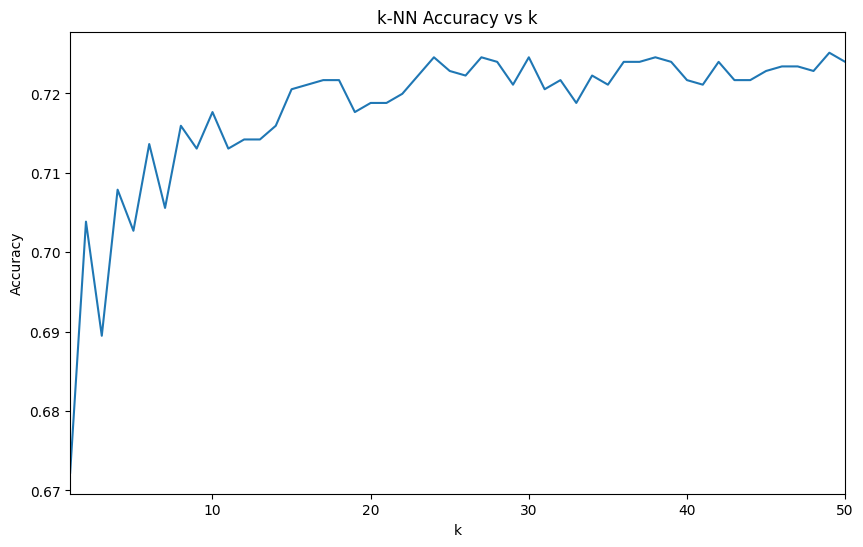

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(range(1, 51), accuracies)
plt.xlim(1, 50)
plt.xlabel('k')
plt.ylabel('Accuracy')
plt.title('k-NN Accuracy vs k')
plt.show()